# DQN - CartPole Reinforcement Learning

This project implements a Deep Q-Network (DQN) in PyTorch to learn how to balance a pole on a moving cart in the CartPole environment.

The agent learns through interaction rather than labeled examples. It observes the environment state, chooses an action, receives a reward, and updates its estimate of future rewards. The notebook covers Q-learning, experience replay, target networks, epsilon-greedy exploration, DQN training, evaluation, and learned action values.

# 1. Import Required Libraries

Load the libraries needed for reinforcement learning, neural-network training, and visualization.


In [1]:
!pip install -q "gymnasium[classic-control]"

import random
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gymnasium as gym

import torch
import torch.nn as nn
import torch.optim as optim

print("PyTorch:", torch.__version__)
print("Gymnasium:", gym.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 75.9 MB/s eta 0:00:00
PyTorch: 2.11.0+cu128
Gymnasium: 1.3.0
CUDA available: True
GPU: Tesla T4


# 2. Configure Reproducibility and Training

Set the random seed, device, and DQN training parameters.


In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ENV_NAME = "CartPole-v1"

NUM_EPISODES = 600
MAX_STEPS = 500

GAMMA = 0.99
LEARNING_RATE = 5e-4

BATCH_SIZE = 64
REPLAY_CAPACITY = 50000
MIN_REPLAY_SIZE = 1000

EPSILON_START = 1.0
EPSILON_END = 0.05
EPSILON_DECAY_STEPS = 10000

TARGET_UPDATE_FREQUENCY = 500
TRAIN_FREQUENCY = 1

print("Device:", DEVICE)


Device: cuda


# 3. Create the CartPole Environment

Create the environment and inspect its state and action spaces.


In [3]:
env = gym.make(ENV_NAME)

state, info = env.reset(seed=SEED)
env.action_space.seed(SEED)

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

print("Environment:", ENV_NAME)
print("State dimension:", state_dim)
print("Number of actions:", action_dim)
print("Initial state:", state)

env.close()


Environment: CartPole-v1
State dimension: 4
Number of actions: 2
Initial state: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]


# 4. Understand the Reinforcement Learning Setup

Review the state, available actions, and reward structure.


In [4]:
env = gym.make(ENV_NAME)

print("State space:", env.observation_space)
print("Action space:", env.action_space)
print("Observation lower bounds:", env.observation_space.low)
print("Observation upper bounds:", env.observation_space.high)

print()
print("Action 0: Move cart left")
print("Action 1: Move cart right")
print()
print("The agent receives a reward of 1 for each time step that the pole remains balanced.")

env.close()


State space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)
Observation lower bounds: [-4.8               -inf -0.41887903        -inf]
Observation upper bounds: [4.8               inf 0.41887903        inf]

Action 0: Move cart left
Action 1: Move cart right

The agent receives a reward of 1 for each time step that the pole remains balanced.


# 5. Build the DQN

Define the neural network used to estimate action values.


In [5]:
class DQN(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )

    def forward(self, state):
        return self.network(state)


policy_net = DQN(state_dim, action_dim).to(DEVICE)
target_net = DQN(state_dim, action_dim).to(DEVICE)

target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

print(policy_net)


DQN(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)


# 6. Inspect the Network Parameters

Check the size of the DQN before training.


In [6]:
total_params = sum(
    parameter.numel()
    for parameter in policy_net.parameters()
)

print("Total parameters:", total_params)


Total parameters: 17410


# 7. Create the Experience Replay Buffer

Store past transitions so the agent can learn from shuffled experiences.


In [7]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def add(self, state, action, reward, next_state, terminated, truncated):
        self.buffer.append(
            (state, action, reward, next_state, terminated, truncated)
        )

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)

        states, actions, rewards, next_states, terminated, truncated = zip(*batch)

        return (
            np.asarray(states, dtype=np.float32),
            np.asarray(actions, dtype=np.int64),
            np.asarray(rewards, dtype=np.float32),
            np.asarray(next_states, dtype=np.float32),
            np.asarray(terminated, dtype=np.float32),
            np.asarray(truncated, dtype=np.float32)
        )

    def __len__(self):
        return len(self.buffer)


replay_buffer = ReplayBuffer(REPLAY_CAPACITY)

print("Replay buffer capacity:", REPLAY_CAPACITY)


Replay buffer capacity: 50000


# 8. Define Exploration and Action Selection

Control exploration with epsilon-greedy action selection.


In [8]:
def get_epsilon(step):
    progress = min(step / EPSILON_DECAY_STEPS, 1.0)
    return EPSILON_START + progress * (EPSILON_END - EPSILON_START)


def select_action(state, epsilon):
    if random.random() < epsilon:
        return random.randrange(action_dim)

    state_tensor = torch.as_tensor(
        state,
        dtype=torch.float32,
        device=DEVICE
    ).unsqueeze(0)

    with torch.no_grad():
        q_values = policy_net(state_tensor)

    return int(q_values.argmax(dim=1).item())


# 9. Define the DQN Optimization Step

Update the policy network using Bellman targets from the target network.


In [9]:
optimizer = optim.Adam(
    policy_net.parameters(),
    lr=LEARNING_RATE
)

loss_function = nn.SmoothL1Loss()


def optimize_model():
    if len(replay_buffer) < MIN_REPLAY_SIZE:
        return None

    states, actions, rewards, next_states, terminated, truncated = replay_buffer.sample(
        BATCH_SIZE
    )

    states = torch.as_tensor(states, dtype=torch.float32, device=DEVICE)
    actions = torch.as_tensor(actions, dtype=torch.long, device=DEVICE).unsqueeze(1)
    rewards = torch.as_tensor(rewards, dtype=torch.float32, device=DEVICE).unsqueeze(1)
    next_states = torch.as_tensor(next_states, dtype=torch.float32, device=DEVICE)

    done = np.maximum(terminated, truncated)
    done = torch.as_tensor(
        done,
        dtype=torch.float32,
        device=DEVICE
    ).unsqueeze(1)

    current_q_values = policy_net(states).gather(1, actions)

    with torch.no_grad():
        next_q_values = target_net(next_states).max(dim=1, keepdim=True).values
        target_q_values = rewards + GAMMA * next_q_values * (1.0 - done)

    loss = loss_function(current_q_values, target_q_values)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(policy_net.parameters(), 10.0)
    optimizer.step()

    return float(loss.item())


# 10. Train the DQN Agent

Train the agent through repeated interaction with CartPole.


In [10]:
env = gym.make(ENV_NAME)

episode_rewards = []
episode_losses = []
episode_epsilons = []

global_step = 0
best_rolling_reward = -np.inf
solved_episode = None

for episode in range(1, NUM_EPISODES + 1):
    state, info = env.reset(seed=SEED + episode)

    total_reward = 0.0
    losses = []

    for step in range(MAX_STEPS):
        epsilon = get_epsilon(global_step)
        action = select_action(state, epsilon)

        next_state, reward, terminated, truncated, info = env.step(action)

        replay_buffer.add(
            state,
            action,
            reward,
            next_state,
            terminated,
            truncated
        )

        state = next_state
        total_reward += reward
        global_step += 1

        if global_step % TRAIN_FREQUENCY == 0:
            loss = optimize_model()
            if loss is not None:
                losses.append(loss)

        if global_step % TARGET_UPDATE_FREQUENCY == 0:
            target_net.load_state_dict(policy_net.state_dict())

        if terminated or truncated:
            break

    episode_rewards.append(total_reward)
    episode_losses.append(np.mean(losses) if losses else np.nan)
    episode_epsilons.append(epsilon)

    rolling_reward = np.mean(episode_rewards[-100:])

    if rolling_reward > best_rolling_reward:
        best_rolling_reward = rolling_reward

    if episode == 1 or episode % 10 == 0:
        print(
            f"Episode {episode:03d} | "
            f"Reward: {total_reward:6.1f} | "
            f"100-Episode Avg: {rolling_reward:6.1f} | "
            f"Epsilon: {epsilon:.3f}"
        )

    if len(episode_rewards) >= 100 and rolling_reward >= 475:
        solved_episode = episode
        print(f"Environment solved at episode {episode}.")
        break

env.close()

print("Episodes completed:", len(episode_rewards))
print("Best 100-episode average:", best_rolling_reward)
print("Solved episode:", solved_episode if solved_episode is not None else "Not reached")


Episode 001 | Reward:   11.0 | 100-Episode Avg:   11.0 | Epsilon: 0.999
Episode 010 | Reward:   22.0 | 100-Episode Avg:   22.3 | Epsilon: 0.979
Episode 020 | Reward:   18.0 | 100-Episode Avg:   21.8 | Epsilon: 0.959
Episode 030 | Reward:   16.0 | 100-Episode Avg:   19.7 | Epsilon: 0.944
Episode 040 | Reward:   26.0 | 100-Episode Avg:   20.3 | Epsilon: 0.923
Episode 050 | Reward:   14.0 | 100-Episode Avg:   20.6 | Epsilon: 0.902
Episode 060 | Reward:   17.0 | 100-Episode Avg:   20.8 | Epsilon: 0.882
Episode 070 | Reward:   36.0 | 100-Episode Avg:   20.3 | Epsilon: 0.865
Episode 080 | Reward:   21.0 | 100-Episode Avg:   21.2 | Epsilon: 0.839
Episode 090 | Reward:   68.0 | 100-Episode Avg:   22.3 | Epsilon: 0.810
Episode 100 | Reward:   35.0 | 100-Episode Avg:   21.9 | Epsilon: 0.793
Episode 110 | Reward:   15.0 | 100-Episode Avg:   21.6 | Epsilon: 0.774
Episode 120 | Reward:   15.0 | 100-Episode Avg:   22.1 | Epsilon: 0.749
Episode 130 | Reward:   22.0 | 100-Episode Avg:   23.3 | Epsilon

# 11. Plot Training Progress

Visualize reward, moving-average reward, loss, and exploration over training.


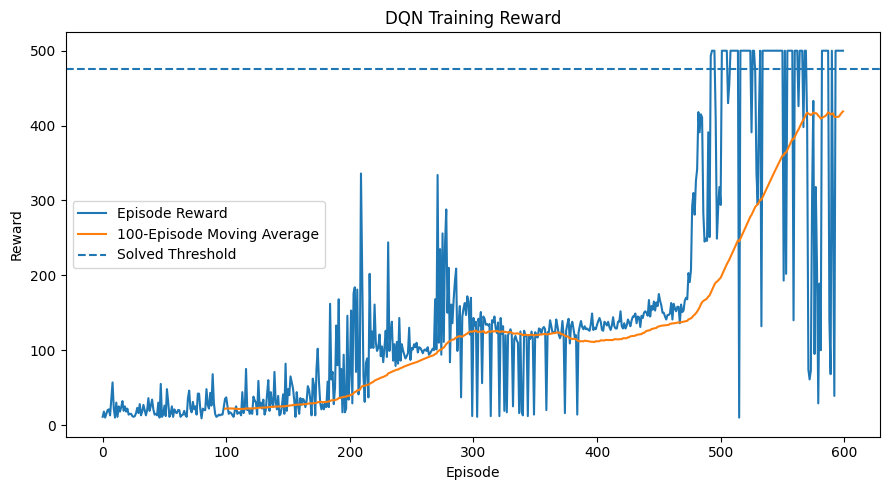

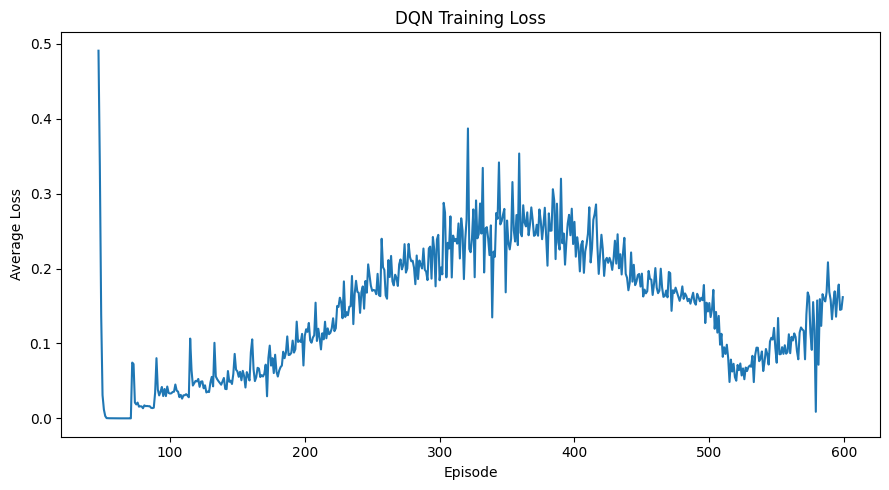

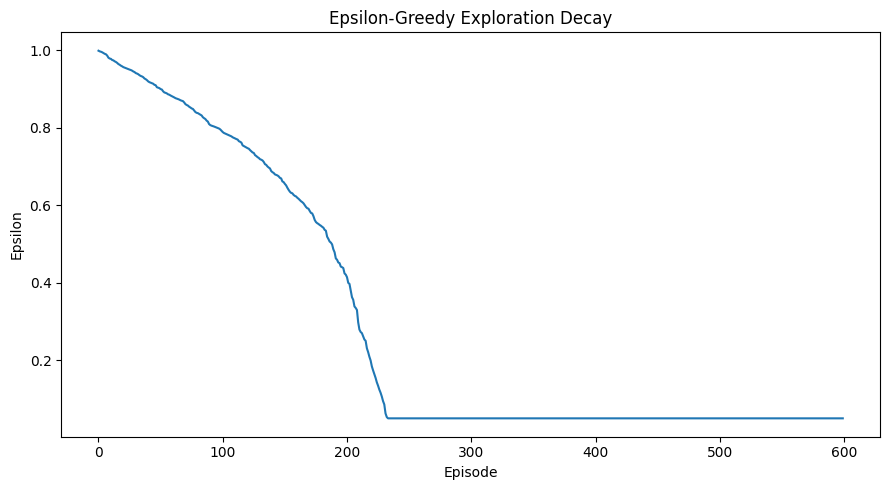

In [11]:
rewards = np.asarray(episode_rewards, dtype=np.float32)
losses = np.asarray(episode_losses, dtype=np.float32)
epsilons = np.asarray(episode_epsilons, dtype=np.float32)

rolling_window = min(100, len(rewards))
rolling_rewards = pd.Series(rewards).rolling(rolling_window).mean()

plt.figure(figsize=(9, 5))
plt.plot(rewards, label="Episode Reward")
plt.plot(rolling_rewards, label=f"{rolling_window}-Episode Moving Average")
plt.axhline(475, linestyle="--", label="Solved Threshold")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("DQN Training Reward")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(losses)
plt.xlabel("Episode")
plt.ylabel("Average Loss")
plt.title("DQN Training Loss")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(epsilons)
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.title("Epsilon-Greedy Exploration Decay")
plt.tight_layout()
plt.show()


# 12. Evaluate the Trained Agent

Measure the learned policy without exploration across multiple episodes.


In [12]:
eval_env = gym.make(ENV_NAME)

evaluation_rewards = []

for episode in range(20):
    state, info = eval_env.reset(seed=1000 + episode)
    total_reward = 0.0

    for step in range(MAX_STEPS):
        action = select_action(state, epsilon=0.0)

        state, reward, terminated, truncated, info = eval_env.step(action)
        total_reward += reward

        if terminated or truncated:
            break

    evaluation_rewards.append(total_reward)

eval_env.close()

print("Evaluation episodes:", len(evaluation_rewards))
print("Mean evaluation reward:", np.mean(evaluation_rewards))
print("Standard deviation:", np.std(evaluation_rewards))
print("Best evaluation reward:", np.max(evaluation_rewards))
print("Minimum evaluation reward:", np.min(evaluation_rewards))


Evaluation episodes: 20
Mean evaluation reward: 500.0
Standard deviation: 0.0
Best evaluation reward: 500.0
Minimum evaluation reward: 500.0


# 13. Compare Evaluation Rewards

Summarize the agent's evaluation performance.


,Episode,Reward
0,1,500.0
1,2,500.0
2,3,500.0
3,4,500.0
4,5,500.0
5,6,500.0
6,7,500.0
7,8,500.0
8,9,500.0
9,10,500.0


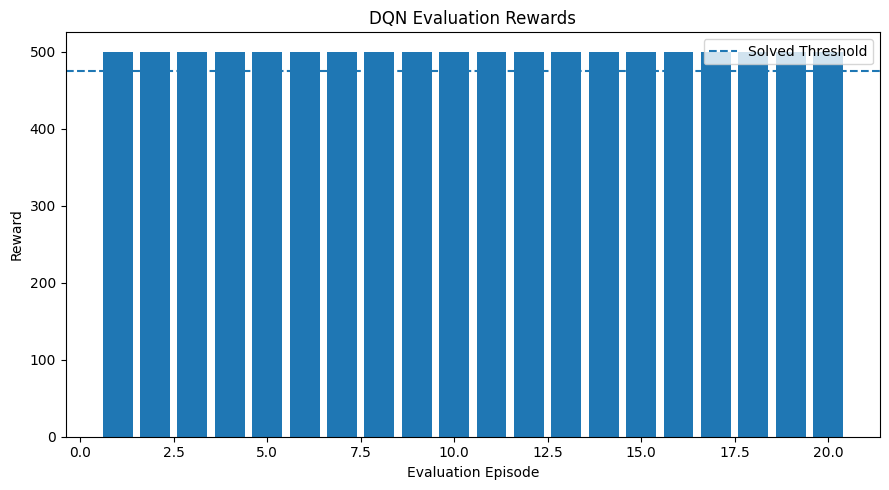

In [13]:
evaluation_summary = pd.DataFrame({
    "Episode": np.arange(1, len(evaluation_rewards) + 1),
    "Reward": evaluation_rewards
})

display(evaluation_summary)

plt.figure(figsize=(9, 5))
plt.bar(
    evaluation_summary["Episode"],
    evaluation_summary["Reward"]
)
plt.axhline(
    475,
    linestyle="--",
    label="Solved Threshold"
)
plt.xlabel("Evaluation Episode")
plt.ylabel("Reward")
plt.title("DQN Evaluation Rewards")
plt.legend()
plt.tight_layout()
plt.show()


# 14. Inspect Learned Q-Values

Examine the action values predicted for representative states.


In [14]:
inspection_env = gym.make(ENV_NAME)

sample_states = []

for seed in [2000, 2001, 2002, 2003, 2004]:
    state, info = inspection_env.reset(seed=seed)
    sample_states.append(state)

inspection_env.close()

sample_tensor = torch.tensor(
    np.asarray(sample_states),
    dtype=torch.float32,
    device=DEVICE
)

with torch.no_grad():
    q_values = policy_net(sample_tensor).cpu().numpy()

q_values_df = pd.DataFrame(
    q_values,
    columns=["Q(Action 0)", "Q(Action 1)"]
)

display(q_values_df)


,Q(Action 0),Q(Action 1)
0,90.445801,90.204628
1,90.220192,90.271751
2,89.710823,89.893990
3,89.916382,89.996811
4,89.776253,90.037422


# 15. Key Findings




# 16. Conclusion


